# News Topic Classification and Summarization with Classical NLP, Transformers, and LLMs

This repository contains the code for my exam project in **Data Analytics with Generative AI and Large Language Models**.

The project applies **classical ML/NLP**, **transformer-based models**, and **large language models (LLMs)** to the **AG News** dataset to:
- Classify news articles into four topics (*World, Sports, Business, Sci/Tech*).
- Discover latent topics with **LDA** and **sentence embeddings + clustering**.
- Generate **class-level** and **topic-level** abstractive summaries using an LLM.
- Perform **qualitative evaluation** of model errors and LLM summaries.

The implementation follows the structure of the report:
- Classical baseline: **TF–IDF + Logistic Regression**
- Transformer classifier: **DistilBERT** fine-tuned on AG News
- Topic modeling: **LDA** on a subset of documents
- Embeddings + clustering: **MiniLM** sentence embeddings + **KMeans** (K = 4)
- Summarization: **DistilBART** for class/topic summaries
- Evaluation: accuracy, macro-F1, confusion matrices, topic/cluster purity, and qualitative analysis

---

## 1. Dataset

- **Dataset:** [AG News](https://huggingface.co/datasets/ag_news)
- **Train:** 120,000 articles  
- **Test:** 7,600 articles  
- **Classes:** `World`, `Sports`, `Business`, `Sci/Tech` (balanced)

The notebook downloads the dataset automatically via the 🤗 `datasets` library, so no manual download is required.

---

## 2. Environment & Dependencies

This project was developed in **Google Colab** using Python and GPU acceleration for the transformer models.

Main libraries:
- `datasets`
- `pandas`, `numpy`
- `scikit-learn`
- `torch`
- `transformers`
- `sentence-transformers`
- `matplotlib`, `seaborn`

You can install the core dependencies with:

```bash
pip install datasets scikit-learn transformers sentence-transformers matplotlib seaborn


In [1]:
# Cell 1: Install and load AG News

!pip install -q datasets

from datasets import load_dataset

# Load the AG News dataset from Hugging Face
dataset = load_dataset("ag_news")

print(dataset)

# Inspect the feature schema for the train split
print("\nFeatures of the train split:")
print(dataset["train"].features)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Features of the train split:
{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}


In [2]:
# Cell 2: Inspect samples, build a unified text field, and basic stats

import pandas as pd
import numpy as np

train_ds = dataset["train"]
test_ds = dataset["test"]

print("Train columns:", train_ds.column_names)
print("Test columns:", test_ds.column_names)

# Detect how text is stored: either "text" or "title"+"description"
def build_text(example):
    cols = train_ds.column_names
    if "text" in cols:
        return example["text"]
    elif all(c in cols for c in ["title", "description"]):
        title = example.get("title", "") or ""
        desc = example.get("description", "") or ""
        return (title + " " + desc).strip()
    else:
        raise ValueError(f"Unexpected columns for text: {cols}")

# Add a unified "full_text" field
train_full_text = [build_text(ex) for ex in train_ds]
test_full_text = [build_text(ex) for ex in test_ds]

train_labels = train_ds["label"]
test_labels = test_ds["label"]

# Map label IDs to names (if available in features)
label_names = train_ds.features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
print("\nLabel mapping (id -> name):", id2label)

# Convert a small sample to pandas for pretty display
df_sample = pd.DataFrame({
    "label_id": train_labels[:5],
    "label_name": [id2label[i] for i in train_labels[:5]],
    "text": train_full_text[:5]
})

print("\nSample rows from the training set:")
display(df_sample)

# Class distribution in the training set
train_label_counts = pd.Series(train_labels).value_counts().sort_index()
train_label_counts.index = [id2label[i] for i in train_label_counts.index]

print("\nClass distribution (train):")
print(train_label_counts)

# Basic text length statistics (in tokens using simple whitespace split)
train_lengths = [len(t.split()) for t in train_full_text]

print("\nBasic text length statistics (train):")
print(f"Number of samples: {len(train_full_text)}")
print(f"Min length: {np.min(train_lengths)}")
print(f"Max length: {np.max(train_lengths)}")
print(f"Mean length: {np.mean(train_lengths):.2f}")
print(f"Median length: {np.median(train_lengths):.2f}")


Train columns: ['text', 'label']
Test columns: ['text', 'label']

Label mapping (id -> name): {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

Sample rows from the training set:


,label_id,label_name,text
0,2,Business,Wall St. Bears Claw Back Into the Black (Reute...
1,2,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,2,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,2,Business,Iraq Halts Oil Exports from Main Southern Pipe...
4,2,Business,"Oil prices soar to all-time record, posing new..."



Class distribution (train):
World       30000
Sports      30000
Business    30000
Sci/Tech    30000
Name: count, dtype: int64

Basic text length statistics (train):
Number of samples: 120000
Min length: 8
Max length: 177
Mean length: 37.85
Median length: 37.00


In [3]:
# Cell 3: Create train/validation split with stratification

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Use the full_text and labels we already built earlier
X = np.array(train_full_text)
y = np.array(train_labels)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Validation size:", len(X_val_text))

# Check label distribution in train and validation
def label_counts(arr, name):
    s = pd.Series(arr).value_counts().sort_index()
    s.index = [id2label[i] for i in s.index]
    print(f"\nLabel distribution in {name}:")
    print(s)

label_counts(y_train, "train split")
label_counts(y_val, "validation split")


Train size: 96000
Validation size: 24000

Label distribution in train split:
World       24000
Sports      24000
Business    24000
Sci/Tech    24000
Name: count, dtype: int64

Label distribution in validation split:
World       6000
Sports      6000
Business    6000
Sci/Tech    6000
Name: count, dtype: int64


TF-IDF shapes:
  Train: (96000, 50000)
  Val:   (24000, 50000)
  Test:  (7600, 50000)

Validation accuracy: 0.9223
Test accuracy:       0.9193

Classification report (test set):
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



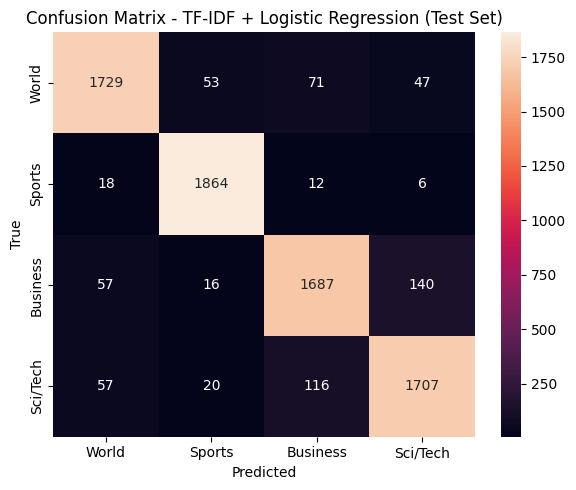

In [4]:
# Cell 4: TF-IDF + Logistic Regression baseline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Build TF-IDF vectorizer on training text
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),       # unigrams + bigrams
    max_features=50000,       # cap vocab for speed/memory
    min_df=2,                 # ignore very rare terms
    stop_words="english"      # remove English stopwords
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)
X_test_tfidf  = tfidf.transform(test_full_text)

print("TF-IDF shapes:")
print("  Train:", X_train_tfidf.shape)
print("  Val:  ", X_val_tfidf.shape)
print("  Test: ", X_test_tfidf.shape)

# 2) Train Logistic Regression classifier
clf = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,          # use all CPU cores
    verbose=0
)
clf.fit(X_train_tfidf, y_train)

# 3) Evaluate on validation and test sets
val_pred  = clf.predict(X_val_tfidf)
test_pred = clf.predict(X_test_tfidf)

val_acc  = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(test_labels, test_pred)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Test accuracy:       {test_acc:.4f}")

print("\nClassification report (test set):")
print(classification_report(test_labels, test_pred, target_names=label_names))

# 4) Confusion matrix on test set
cm = confusion_matrix(test_labels, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_names,
            yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - TF-IDF + Logistic Regression (Test Set)")
plt.tight_layout()
plt.show()


In [5]:
# Cell 5 (fixed): LDA topic modeling on a subset of AG News

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# To keep things fast, use a subset for LDA (you can increase if Colab is fast)
N_DOCS_FOR_LDA = 20000  # try 20k; you can change to e.g. 40000 if it's smooth

rng = np.random.RandomState(42)
subset_indices = rng.choice(len(train_full_text), size=N_DOCS_FOR_LDA, replace=False)

# Convert labels to a NumPy array so we can index with NumPy ints
labels_array = np.array(train_labels)

subset_texts = [train_full_text[int(i)] for i in subset_indices]
subset_labels = labels_array[subset_indices].tolist()

print(f"Using {len(subset_texts)} documents for LDA topic modeling.")

# Bag-of-words representation
count_vectorizer = CountVectorizer(
    max_df=0.95,       # ignore terms that appear in >95% of docs
    min_df=5,          # ignore very rare terms
    max_features=10000,
    stop_words="english"
)

X_counts = count_vectorizer.fit_transform(subset_texts)
print("Document-term matrix shape:", X_counts.shape)

# LDA model
N_TOPICS = 10  # you can adjust to 8, 12, etc.
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=10,
    learning_method="batch",
    random_state=42,
    n_jobs=-1
)

doc_topic_distr = lda.fit_transform(X_counts)
print("Doc-topic distribution shape:", doc_topic_distr.shape)

# Function to display top words per topic
def print_top_words(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Topic #{topic_idx}:")
        print("  " + ", ".join(top_words))
        print()

tf_feature_names = count_vectorizer.get_feature_names_out()
print("\nTop words per topic:")
print_top_words(lda, tf_feature_names, n_top_words=12)


Using 20000 documents for LDA topic modeling.
Document-term matrix shape: (20000, 10000)
Doc-topic distribution shape: (20000, 10)

Top words per topic:
Topic #0:
  39, microsoft, internet, company, said, software, corp, new, service, online, billion, million

Topic #1:
  quot, 39, said, space, chief, israeli, ap, gaza, palestinian, year, nasa, canadian

Topic #2:
  39, president, ap, bush, said, iraq, election, reuters, afp, nuclear, government, iran

Topic #3:
  oil, prices, reuters, stocks, new, dollar, record, york, economy, high, said, friday

Topic #4:
  39, india, killed, people, said, city, baghdad, ap, north, bomb, sunday, test

Topic #5:
  said, 39, talks, union, new, reuters, deal, million, european, eu, united, darfur

Topic #6:
  39, sales, quarter, profit, said, year, percent, earnings, reuters, company, google, reported

Topic #7:
  39, ap, game, win, gt, lt, reuters, fullquote, new, night, season, victory

Topic #8:
  new, 39, ibm, mobile, computer, search, apple, techn

In [6]:
# Cell 6: Analyze topic–label alignment

import pandas as pd

# For each document in the LDA subset, pick the dominant topic
dominant_topics = doc_topic_distr.argmax(axis=1)

# Build a DataFrame with topic and label
df_topics = pd.DataFrame({
    "topic": dominant_topics,
    "label_id": subset_labels
})
df_topics["label_name"] = df_topics["label_id"].map(id2label)

# Crosstab: how many docs of each label fall into each topic
topic_label_counts = pd.crosstab(df_topics["topic"], df_topics["label_name"])

print("Topic–label count table:")
display(topic_label_counts)

# Also show row-normalized version (each topic as percentages over labels)
topic_label_pct = topic_label_counts.div(topic_label_counts.sum(axis=1), axis=0).round(3)

print("\nTopic–label percentage table (rows sum to 1.0):")
display(topic_label_pct)

# Optionally, join top words + dominant label for a compact summary
topic_summaries = []

for topic_idx in range(lda.n_components):
    # top words
    top_indices = lda.components_[topic_idx].argsort()[:-11:-1]
    top_words = [tf_feature_names[i] for i in top_indices]

    # most common label for this topic
    if topic_idx in topic_label_counts.index:
        dominant_label = topic_label_counts.loc[topic_idx].idxmax()
    else:
        dominant_label = "N/A"

    topic_summaries.append({
        "topic": topic_idx,
        "top_words": ", ".join(top_words),
        "dominant_label": dominant_label
    })

df_topic_summary = pd.DataFrame(topic_summaries)
print("\nSummary of topics with top words and dominant label:")
display(df_topic_summary)


Topic–label count table:


label_name,Business,Sci/Tech,Sports,World
topic,,,,
0,1086,1430,34,80
1,301,476,327,762
2,236,363,107,1945
3,1235,102,34,142
4,67,111,1162,1009
5,656,184,82,659
6,821,212,112,49
7,193,92,2889,144
8,257,1720,59,29



Topic–label percentage table (rows sum to 1.0):


label_name,Business,Sci/Tech,Sports,World
topic,,,,
0,0.413,0.544,0.013,0.030
1,0.161,0.255,0.175,0.408
2,0.089,0.137,0.040,0.734
3,0.816,0.067,0.022,0.094
4,0.029,0.047,0.495,0.430
5,0.415,0.116,0.052,0.417
6,0.688,0.178,0.094,0.041
7,0.058,0.028,0.871,0.043
8,0.124,0.833,0.029,0.014



Summary of topics with top words and dominant label:


,topic,top_words,dominant_label
0,0,"39, microsoft, internet, company, said, softwa...",Sci/Tech
1,1,"quot, 39, said, space, chief, israeli, ap, gaz...",World
2,2,"39, president, ap, bush, said, iraq, election,...",World
3,3,"oil, prices, reuters, stocks, new, dollar, rec...",Business
4,4,"39, india, killed, people, said, city, baghdad...",Sports
5,5,"said, 39, talks, union, new, reuters, deal, mi...",World
6,6,"39, sales, quarter, profit, said, year, percen...",Business
7,7,"39, ap, game, win, gt, lt, reuters, fullquote,...",Sports
8,8,"new, 39, ibm, mobile, computer, search, apple,...",Sci/Tech
9,9,"gt, lt, red, sox, world, boston, arafat, new, ...",Sci/Tech


In [7]:
# Cell 7: Compute sentence embeddings for a subset of AG News

!pip install -q sentence-transformers umap-learn

from sentence_transformers import SentenceTransformer
import torch
import numpy as np
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Subset size for embeddings (adjust if needed)
N_EMB = 20000

rng = np.random.RandomState(123)
emb_indices = rng.choice(len(train_full_text), size=N_EMB, replace=False)

# Build subset texts and labels
labels_array = np.array(train_labels)
emb_texts = [train_full_text[int(i)] for i in emb_indices]
emb_labels = labels_array[emb_indices]

print(f"Encoding {len(emb_texts)} documents for embeddings...")

# Load a compact sentence-transformer model
model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# Encode texts (this will automatically use GPU if available)
embeddings = model.encode(
    emb_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embeddings shape:", embeddings.shape)

# Put labels into a DataFrame for later analysis
df_emb = pd.DataFrame({
    "label_id": emb_labels,
    "label_name": [id2label[int(i)] for i in emb_labels]
})

df_emb.head()


Using device: cuda
Encoding 20000 documents for embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings shape: (20000, 384)


,label_id,label_name
0,1,Sports
1,1,Sports
2,1,Sports
3,3,Sci/Tech
4,0,World


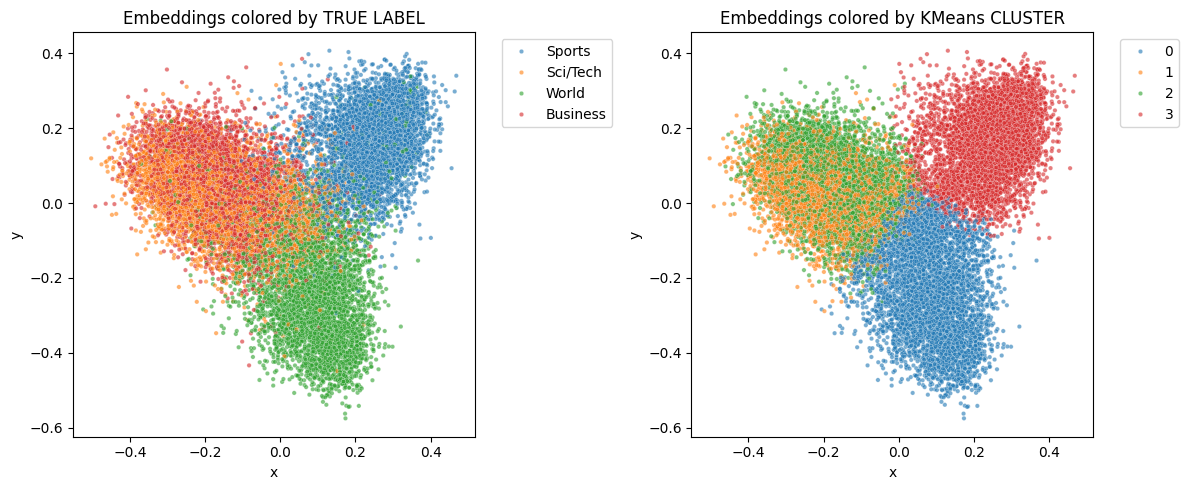

Cluster vs label counts:
label_name  Business  Sci/Tech  Sports  World
cluster                                      
0                266       721      83   4317
1                745      3715      16    102
2               3938       449      72    315
3                 79       121    4822    239

Cluster vs label percentage (rows sum to 1.0):
label_name  Business  Sci/Tech  Sports  World
cluster                                      
0              0.049     0.134   0.015  0.801
1              0.163     0.811   0.003  0.022
2              0.825     0.094   0.015  0.066
3              0.015     0.023   0.917  0.045


In [8]:
# Cell 8: PCA + KMeans clustering and visualization

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Dimensionality reduction to 2D for plotting
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)

df_emb["x"] = emb_2d[:, 0]
df_emb["y"] = emb_2d[:, 1]

# 2) KMeans clustering in embedding space
K = 4  # we know there are 4 true classes
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

df_emb["cluster"] = clusters

# 3) Plot embeddings colored by true label and by cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    ax=axes[0],
    data=df_emb,
    x="x", y="y",
    hue="label_name",
    s=10, alpha=0.6
)
axes[0].set_title("Embeddings colored by TRUE LABEL")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

sns.scatterplot(
    ax=axes[1],
    data=df_emb,
    x="x", y="y",
    hue="cluster",
    palette="tab10",
    s=10, alpha=0.6
)
axes[1].set_title("Embeddings colored by KMeans CLUSTER")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# 4) Cluster vs label crosstab
cluster_label_counts = pd.crosstab(df_emb["cluster"], df_emb["label_name"])
print("Cluster vs label counts:")
print(cluster_label_counts)

cluster_label_pct = cluster_label_counts.div(cluster_label_counts.sum(axis=1), axis=0).round(3)
print("\nCluster vs label percentage (rows sum to 1.0):")
print(cluster_label_pct)


In [9]:
# Cell 9: Prepare DistilBERT datasets (train/val/test)

!pip install -q transformers

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from datasets import Dataset
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 1) Load tokenizer & model
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

num_labels = len(label_names)
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id={v:k for k, v in id2label.items()}
).to(device)

# 2) Tokenize text data
max_length = 128  # enough for our ~38-word snippets

def tokenize_batch(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_length
    )

print("Tokenizing train/val/test splits...")
train_encodings = tokenize_batch(X_train_text)
val_encodings   = tokenize_batch(X_val_text)
test_encodings  = tokenize_batch(test_full_text)

# 3) Build Dataset objects
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": list(y_train)
})
val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": list(y_val)
})
test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": list(test_labels)
})

# Set format for PyTorch
train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")
test_dataset.set_format(type="torch")

print(train_dataset)
print(val_dataset)
print(test_dataset)


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizing train/val/test splits...
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 96000
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 24000
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 7600
})


In [10]:
# Cell 10 (fixed): Train DistilBERT classifier with manual loop

from torch.utils.data import DataLoader
from torch.optim import AdamW      # <-- use PyTorch AdamW
from tqdm.auto import tqdm
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model.to(device)

batch_size = 16
num_epochs = 2           # you can set to 3 if runtime is okay
learning_rate = 2e-5

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

optimizer = AdamW(model.parameters(), lr=learning_rate)

def evaluate_model(model, data_loader):
    model.eval()
    all_labels = []
    all_preds = []
    total_loss = 0.0
    loss_fn = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item() * input_ids.size(0)

            preds = torch.argmax(logits, dim=-1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    from sklearn.metrics import accuracy_score, precision_recall_fscore_support
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_precision": prec,
        "macro_recall": rec,
        "macro_f1": f1,
    }

# Training loop
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    print(f"  Train loss: {avg_train_loss:.4f}")

    # Validation evaluation
    val_metrics = evaluate_model(model, val_loader)
    print(f"  Val loss: {val_metrics['loss']:.4f} | "
          f"Val acc: {val_metrics['accuracy']:.4f} | "
          f"Val macro-F1: {val_metrics['macro_f1']:.4f}")


Using device: cuda

Epoch 1/2


  0%|          | 0/6000 [00:00<?, ?it/s]

  Train loss: 0.2264
  Val loss: 0.1633 | Val acc: 0.9445 | Val macro-F1: 0.9446

Epoch 2/2


  0%|          | 0/6000 [00:00<?, ?it/s]

  Train loss: 0.1347
  Val loss: 0.1650 | Val acc: 0.9438 | Val macro-F1: 0.9439


Test accuracy:         0.9428
Test macro precision:  0.9433
Test macro recall:     0.9428
Test macro F1:         0.9429

Classification report (test set):
              precision    recall  f1-score   support

       World       0.96      0.95      0.95      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.89      0.93      0.91      1900
    Sci/Tech       0.93      0.90      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



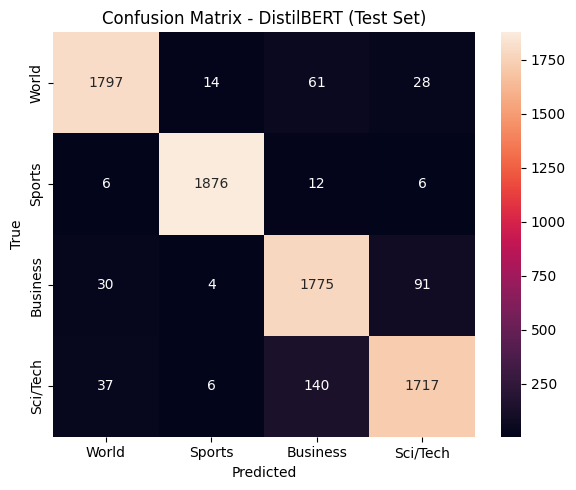

In [11]:
# Cell 11: Evaluate trained DistilBERT on the test set

from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def get_preds_and_labels(model, data_loader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

y_true_test, y_pred_test = get_preds_and_labels(model, test_loader)

acc = accuracy_score(y_true_test, y_pred_test)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true_test, y_pred_test, average="macro", zero_division=0
)

print(f"Test accuracy:         {acc:.4f}")
print(f"Test macro precision:  {prec:.4f}")
print(f"Test macro recall:     {rec:.4f}")
print(f"Test macro F1:         {f1:.4f}")

print("\nClassification report (test set):")
print(classification_report(y_true_test, y_pred_test, target_names=label_names))

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_names,
            yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DistilBERT (Test Set)")
plt.tight_layout()
plt.show()


In [12]:
# Cell 12: Prepare per-class text samples for summarization

import pandas as pd
import numpy as np

# Build a DataFrame from the full training data
df_train_full = pd.DataFrame({
    "text": train_full_text,
    "label_id": train_labels
})
df_train_full["label_name"] = df_train_full["label_id"].map(id2label)

# How many examples per class to include in each summary input
N_PER_CLASS = 20  # you can increase later if GPU/memory is fine

rng = np.random.RandomState(42)

class_text_blocks = {}

for label_id, label_name in id2label.items():
    df_class = df_train_full[df_train_full["label_id"] == label_id]
    sample_rows = df_class.sample(n=N_PER_CLASS, random_state=rng)

    # Join texts with separators so the summarizer sees multiple examples
    long_text = "\n".join(
        "- " + t.replace("\n", " ") for t in sample_rows["text"].tolist()
    )

    class_text_blocks[label_name] = long_text

for label_name, long_text in class_text_blocks.items():
    print(f"\n=== {label_name} ===")
    print(long_text[:400], "...")
    print(f"(Total characters: {len(long_text)})")



=== World ===
- Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.
- BBC reporters' log BBC correspondents record events in the Middle East and their thoughts as the funeral of the Palestinian leader Yasser Arafat take ...
(Total characters: 4792)

=== Sports ===
- Three Share Pebble Beach Lead (AP) AP - Former tournament winner Kirk Triplett and PGA Tour rookie Ryan Palmer shot 6-under 66s on Friday and share a one-stroke lead with reigning Nationwide Tour champion Nick Watney after two rounds of the Pebble Beach Invitational.
- Friedgen #39;s QB call: Gametime Terrapin quarterbacks Joel Statham and Jordan Steffy will compete the remainder of the week to  ...
(Total characters: 4498)

=== Business ===
- Drug approval process flawed THE US pharmaceutical industry that exports medicines around

In [14]:
# Cell 13 (fixed): Generate class-level summaries with a summarization LLM (BART)

from transformers import pipeline
import torch

# Force CPU to avoid CUDA asserts for long inputs
device = -1
print("Using device for summarization: cpu")

# Smaller BART variant (lighter than full bart-large-cnn)
model_name = "sshleifer/distilbart-cnn-12-6"

summarizer = pipeline(
    "summarization",
    model=model_name,
    device=device
)

class_summaries = {}

# To be safe, truncate very long text blocks (model has a max input length)
MAX_CHARS = 2500  # adjust if you like; smaller = faster, but less context

for label_name, long_text in class_text_blocks.items():
    print(f"\n### Summarizing class: {label_name}")

    input_text = long_text[:MAX_CHARS]  # truncate to avoid overly long sequences

    summary = summarizer(
        input_text,
        max_length=120,   # target summary length (tokens)
        min_length=40,    # encourage some detail
        do_sample=False   # deterministic decoding
    )[0]["summary_text"]

    class_summaries[label_name] = summary
    print(summary)


Using device for summarization: cpu


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cpu



### Summarizing class: World
 A car bomb explodes near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others . Medical Journal calls for a new drug watchdog to detect harmful effects of drugs already on the market . Israel welcomes Rice nomination; Palestinians wary, saying Bush administration must put more energy into quest for peace .

### Summarizing class: Sports
 Tennessee Titans receiver Tyrone Calico will have surgery Thursday to repair torn cartilage in his left knee . Former tournament winner Kirk Triplett and PGA Tour rookie Ryan Palmer share a one-stroke lead at Pebble Beach Invitational . Retief Goosen knew how to finish, with a brilliant six-under-par 64 .

### Summarizing class: Business
 Red Hat (NOVL:Nasdaq - news - research) got its second upgrade in two week Tuesday . Shell bosses in a charm offensive to boost morale and explain plans to unify the company ahead of the vote on the shake-up at next M

In [15]:
# Cell 14: LDA topic-level summaries with DistilBART

import numpy as np

N_DOCS_PER_TOPIC = 15      # how many docs to sample per topic
TOP_WORDS_PER_TOPIC = 10   # how many top words to show
MAX_TOPIC_CHARS = 2000     # truncate input to keep it safe

topic_summaries = {}

for topic_idx in range(lda.n_components):
    print(f"\n=== Topic {topic_idx} ===")

    # Top words for this topic
    top_indices = lda.components_[topic_idx].argsort()[:-TOP_WORDS_PER_TOPIC - 1:-1]
    top_words = [tf_feature_names[i] for i in top_indices]
    print("Top words:", ", ".join(top_words))

    # Get indices of docs where this topic is strongest
    topic_strengths = doc_topic_distr[:, topic_idx]
    top_doc_indices = np.argsort(topic_strengths)[-N_DOCS_PER_TOPIC:]

    topic_docs = [subset_texts[i].replace("\n", " ") for i in top_doc_indices]
    # Build block: show words + bullet list of docs
    doc_block = "\n".join(f"- {t}" for t in topic_docs)

    long_text = (
        "Topic keywords: " + ", ".join(top_words) + "\n\n"
        "Example news snippets:\n" + doc_block
    )

    input_text = long_text[:MAX_TOPIC_CHARS]

    summary = summarizer(
        input_text,
        max_length=80,
        min_length=30,
        do_sample=False
    )[0]["summary_text"]

    topic_summaries[topic_idx] = {
        "top_words": top_words,
        "summary": summary,
    }

    print("Summary:", summary)



=== Topic 0 ===
Top words: 39, microsoft, internet, company, said, software, corp, new, service, online
Summary:  The entertainment industry is calling for the US Supreme Court to overturn the Grokster / Morpheus ruling that says p2p networks aren #39;t liable for alleged copyright violations committed by users . Microsoft announced this week it is making the programming code for its Office 2003 software suite available to government agencies around the globe, a move partly aimed at allowing them to inspect the product for flaws

=== Topic 1 ===
Top words: quot, 39, said, space, chief, israeli, ap, gaza, palestinian, year
Summary:  The 850 strong battle group pulled out of Camp Dogwood and returned to Basra yesterday . Israeli troops killed four Palestinians,  including a militant and a 10-year-old girl, in northern Gaza . Slobodan Milosevic angrily refused to work with two court-appointed lawyers Tuesday .

=== Topic 2 ===
Top words: 39, president, ap, bush, said, iraq, election, reu

In [16]:
# Cell 15: Sample misclassified examples from DistilBERT classifier

import pandas as pd

# If y_true_test / y_pred_test are not in memory (e.g. notebook restart),
# you can re-run Cell 11 first. Otherwise, we reuse them here.

print("Total test samples:", len(test_full_text))
print("Total mismatches:", (y_true_test != y_pred_test).sum())

mis_idx = [i for i, (yt, yp) in enumerate(zip(y_true_test, y_pred_test)) if yt != yp]

# Sample up to 20 misclassified examples for inspection
N_MIS = min(20, len(mis_idx))
rng = np.random.RandomState(123)
sampled_mis_idx = rng.choice(mis_idx, size=N_MIS, replace=False)

rows = []
for i in sampled_mis_idx:
    rows.append({
        "true_label": id2label[int(y_true_test[i])],
        "pred_label": id2label[int(y_pred_test[i])],
        "text": test_full_text[i]
    })

df_mis = pd.DataFrame(rows)
df_mis = df_mis[["true_label", "pred_label", "text"]]

print("\nSampled misclassified examples (for qualitative analysis):")
pd.set_option("display.max_colwidth", 200)
display(df_mis)
pd.set_option("display.max_colwidth", 50)  # reset if you want


Total test samples: 7600
Total mismatches: 435

Sampled misclassified examples (for qualitative analysis):


,true_label,pred_label,text
0,Sci/Tech,Business,Bill Clinton Helps Launch Search Engine Former president Bill Clinton on Monday helped launch a new Internet search company backed by the Chinese government which says its technology uses artifici...
1,World,Business,"China's inflation rate slows sharply but problems remain (AFP) AFP - China's inflation rate eased sharply in October as government efforts to cool the economy began to really bite, with food price..."
2,World,Business,"In Indonesia, Businesses Hopeful After Election After suffering through two shambling administrations, Indonesia appears to have a new president who many of its business leaders say they believe w..."
3,Business,Sci/Tech,"Nintendo to Unveil Handheld Upgrade Facing its biggest threat ever from the arrival of Sony Corp. in the portable video-game machine market, Japanese game-maker Nintendo Co."
4,Business,Sci/Tech,"SIA: Chip sales to hit record, flatten Worldwide semiconductor sales will hit an all-time high in 2004 but stay relatively flat in 2005 before climbing again over the next two years, according to ..."
5,Sci/Tech,World,The Shockwaves of Sumatra The Indian Ocean earthquake of December 2004 produced a shockwave that created tsunamis all across the Indian Ocean. The tsunamis hammered nearby Indonesia and struck...
6,Sci/Tech,World,"Serial HIV Assault Verdict Expected Mon. (AP) AP - A verdict will be announced Monday in the trial of a man charged with intentionally exposing 17 women to HIV, a county judge said."
7,Sci/Tech,Business,"Ciena Posts a Loss, Forecasts Flat Sales &lt;p&gt;&lt;/p&gt;&lt;p&gt; By Deborah Cohen&lt;/p&gt;&lt;p&gt; CHICAGO (Reuters) - Telecommunications equipment makerCiena Corp. &lt;CIEN.O&gt; on Thursd..."
8,Sci/Tech,Business,"Intuit Posts Wider Loss After Charge (Reuters) Reuters - Intuit Inc. (INTU.O), maker of\the No. 1 U.S. tax presentation software TurboTax, on Wednesday\posted a wider quarterly loss after taking a..."
9,Sports,World,"Madrid miffed! The organisers of Madrid #39;s bid complained that Paris had broken the rules by using France #39;s embassies in Oslo and Kuwait to hold events to promote its candidacy, the newspap..."


In [4]:
import nbformat
from google.colab import files

path = '/content/ag_news_analytics.ipynb'  # adjust if different

nb = nbformat.read(path, as_version=4)

# Remove top-level widgets metadata
nb.metadata.pop('widgets', None)

# Remove widgets metadata from cells
for cell in nb.cells:
    cell.metadata.pop('widgets', None)

cleaned_path = 'ag_news_analytics_clean.ipynb'
nbformat.write(nb, cleaned_path)

files.download(cleaned_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>